In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\91636\Desktop\major_project\New folder\cyber\Phishing_Email.csv")
print(df.columns)
print(df.head())


Index(['Unnamed: 0', 'Email Text', 'Email Type'], dtype='object')
   Unnamed: 0                                         Email Text  \
0           0  re : 6 . 1100 , disc : uniformitarianism , re ...   
1           1  the other side of * galicismos * * galicismo *...   
2           2  re : equistar deal tickets are you still avail...   
3           3  \nHello I am your hot lil horny toy.\n    I am...   
4           4  software at incredibly low prices ( 86 % lower...   

       Email Type  
0      Safe Email  
1      Safe Email  
2      Safe Email  
3  Phishing Email  
4  Phishing Email  


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve,
    average_precision_score, confusion_matrix, classification_report
)
import joblib
import numpy as np

# ==== Config ====
DATA_PATH = r"C:\Users\91636\Desktop\major_project\New folder\cyber\Phishing_Email.csv"
OUTPUT_DIR = "phishing_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==== Load dataset ====
df = pd.read_csv(DATA_PATH)

# Rename label column
df = df.rename(columns={'Email Type': 'label'})

# Convert labels to binary: 1 = Phishing, 0 = Safe
df['label'] = df['label'].apply(lambda x: 1 if "phishing" in x.lower() else 0)

# ==== Features (text) and labels ====
X_text = df['Email Text'].fillna("")   # fill NaN with empty string
y = df['label']

# ==== TF-IDF Vectorization ====
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1,2)
)
X = vectorizer.fit_transform(X_text)

# ==== Train-test split ====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==== Models ====
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric="logloss"
    )
}

best_model, best_auc = None, 0

for name, model in models.items():
    print(f"\n=== Training {name} ===")
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = model.predict(X_test)

    auc = roc_auc_score(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    print(f"{name} -> ROC AUC: {auc:.4f}, AP: {ap:.4f}")
    print(classification_report(y_test, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} - ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(OUTPUT_DIR, f"roc_{name}.png"))
    plt.close()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.figure()
    plt.plot(recall, precision, label=f"AP={ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{name} - PR Curve")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(OUTPUT_DIR, f"pr_{name}.png"))
    plt.close()

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    plt.imshow(cm, cmap="Blues", interpolation="nearest")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for (i, j), val in np.ndenumerate(cm):
        plt.text(j, i, int(val), ha='center', va='center', color="red")
    plt.savefig(os.path.join(OUTPUT_DIR, f"cm_{name}.png"))
    plt.close()

    # Track best model
    if auc > best_auc:
        best_auc = auc
        best_model = model

# ==== Save best model & vectorizer ====
joblib.dump(best_model, os.path.join(OUTPUT_DIR, "best_phishing_model.joblib"))
joblib.dump(vectorizer, os.path.join(OUTPUT_DIR, "vectorizer_phishing.joblib"))
print(f"\n✅ Best model saved with AUC={best_auc:.3f} in {OUTPUT_DIR}")



=== Training LogReg ===
LogReg -> ROC AUC: 0.9943, AP: 0.9902
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2264
           1       0.94      0.97      0.95      1466

    accuracy                           0.96      3730
   macro avg       0.96      0.96      0.96      3730
weighted avg       0.96      0.96      0.96      3730


=== Training RandomForest ===
RandomForest -> ROC AUC: 0.9877, AP: 0.9791
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      2264
           1       0.92      0.94      0.93      1466

    accuracy                           0.94      3730
   macro avg       0.94      0.94      0.94      3730
weighted avg       0.94      0.94      0.94      3730


=== Training XGBoost ===


c:\Users\91636\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:35:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost -> ROC AUC: 0.9936, AP: 0.9880
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      2264
           1       0.92      0.98      0.95      1466

    accuracy                           0.96      3730
   macro avg       0.95      0.96      0.96      3730
weighted avg       0.96      0.96      0.96      3730


✅ Best model saved with AUC=0.994 in phishing_output


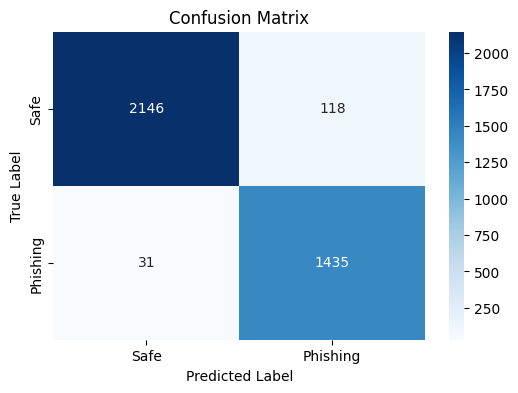

Classification Report:
               precision    recall  f1-score   support

        Safe       0.99      0.95      0.97      2264
    Phishing       0.92      0.98      0.95      1466

    accuracy                           0.96      3730
   macro avg       0.95      0.96      0.96      3730
weighted avg       0.96      0.96      0.96      3730



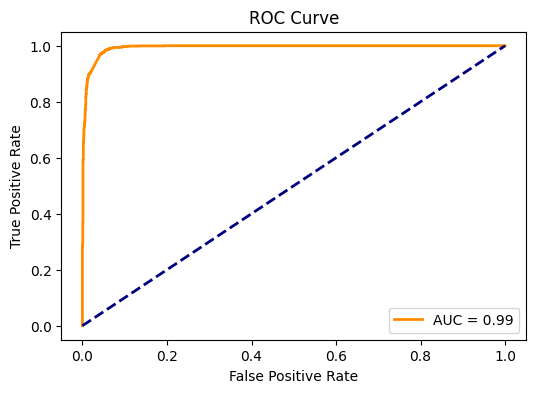

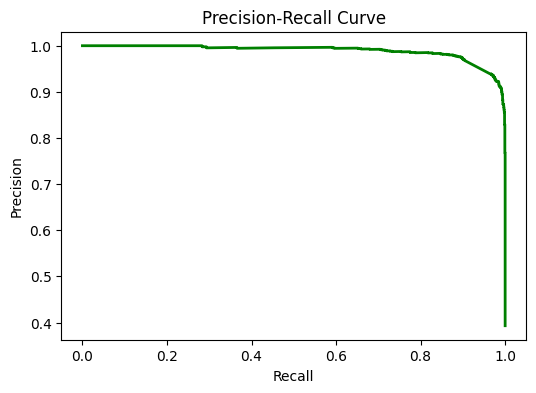

C:\Users\91636\AppData\Local\Temp\ipykernel_764\1853757821.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="Set2")


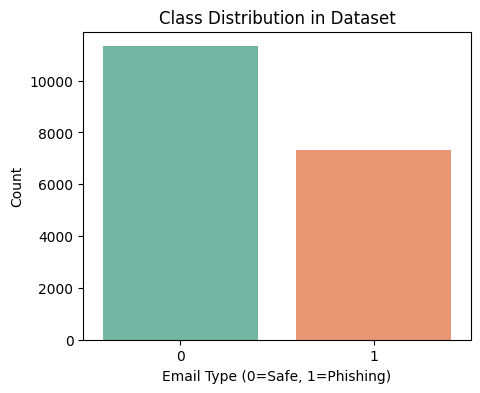

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, 
    precision_recall_curve
)

# ==== Predictions ====
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # probability for positive class

# ==== Confusion Matrix ====
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Safe","Phishing"], yticklabels=["Safe","Phishing"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ==== Classification Report ====
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=["Safe","Phishing"]))

# ==== ROC Curve ====
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# ==== Precision-Recall Curve ====
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, color="green", lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# ==== Class Distribution ====
plt.figure(figsize=(5,4))
sns.countplot(x=y, palette="Set2")
plt.title("Class Distribution in Dataset")
plt.xlabel("Email Type (0=Safe, 1=Phishing)")
plt.ylabel("Count")
plt.show()


In [6]:
import joblib

# ==== Save the model ====
model_filename = "phishing_email_model.pkl"
joblib.dump(model, model_filename)

print(f"Model saved as {model_filename}")


Model saved as phishing_email_model.pkl
